In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Datasheet/credit_card_fraud_10k.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [3]:
df.head(5)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [5]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [6]:
df['is_fraud'].value_counts(normalize=True)*100

,proportion
is_fraud,
0,98.49
1,1.51


In [7]:
df.drop(columns='transaction_id',inplace=True)

In [8]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

**Feature Engineering**

In [9]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['transaction_hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['transaction_hour']/24)

In [10]:
df.columns

Index(['amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud', 'hour_sin',
       'hour_cos'],
      dtype='object')

**Preprocessing**

In [11]:
Feature = ['amount','hour_sin','hour_cos', 'foreign_transaction', 'location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X = df[Feature]
y = df['is_fraud']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify= y)
print(f"Jumlah data training sebanyak : {len(X_train)} dan jumlah data uji sebanyak :{len(X_test)}")

Jumlah data training sebanyak : 8000 dan jumlah data uji sebanyak :2000


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_feature = ['amount','device_trust_score','velocity_last_24h','cardholder_age']
num_transform = scaler

In [14]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_transform, num_feature)
], remainder = 'passthrough')

In [15]:
from sklearn.svm import SVC

baseline_svc = SVC(probability=True, random_state=42)

**Model Baseline**

In [16]:
from sklearn.pipeline import Pipeline

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', baseline_svc)
])

In [17]:
baseline_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model', SVC(probability=True, random_state=42))])

In [18]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
print(f"Akurasi Model Baseline : {accuracy_baseline:.4f}")
print(f"Precision Baseline : {precision_baseline:.4f}")
print(f"Recall Baseline : {recall_baseline:.4f}")
print(classification_report(y_test, y_pred_baseline))

Akurasi Model Baseline : 0.9930
Precision Baseline : 0.9444
Recall Baseline : 0.5667
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.94      0.57      0.71        30

    accuracy                           0.99      2000
   macro avg       0.97      0.78      0.85      2000
weighted avg       0.99      0.99      0.99      2000



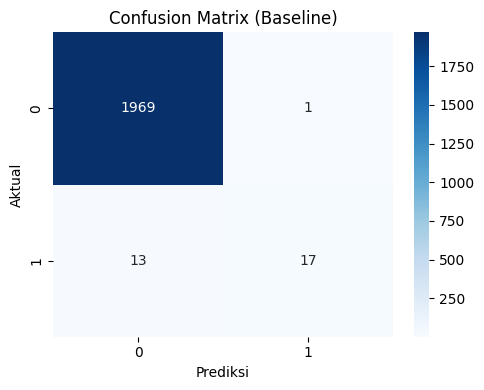

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [24]:
y_prob_baseline = baseline_pipeline.predict_proba(X_test)[:,1]

In [25]:
roc_auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f'ROC AUC score baseline = {roc_auc_baseline:.4f}')

ROC AUC score baseline = 0.9959


**SVM + Class Wegiht Balanced**

In [26]:
balanced_svc = SVC(class_weight='balanced', probability=True, random_state=42)

In [27]:
balanced_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', balanced_svc)
])

In [28]:
balanced_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [29]:
y_pred_balanced = balanced_pipeline.predict(X_test)

In [30]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
print(f'Akurasi model dengan balanced :{accuracy_balanced:.4f}')
print(f'Precision model dengan balanced :{precision_balanced:.4f}')
print(f'Recall model dengan balanced :{recall_balanced:.4f}')
print(classification_report(y_test, y_pred_balanced))

Akurasi model dengan balanced :0.9840
Precision model dengan balanced :0.4821
Recall model dengan balanced :0.9000
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.48      0.90      0.63        30

    accuracy                           0.98      2000
   macro avg       0.74      0.94      0.81      2000
weighted avg       0.99      0.98      0.99      2000



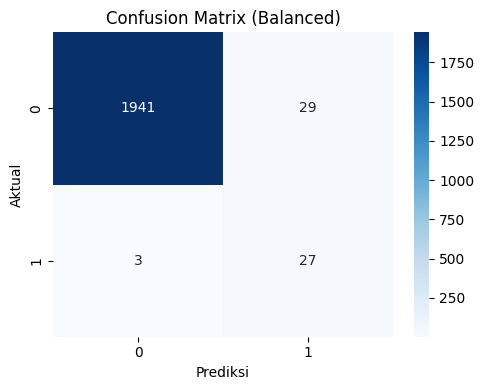

In [31]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Balanced)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [32]:
y_prob_balanced = balanced_pipeline.predict_proba(X_test)[:,1]

In [33]:
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)
print(f'ROC AUC score balanced = {roc_auc_balanced:.4f}')

ROC AUC score balanced = 0.9961


**SVM + SMOTE**

In [35]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', balanced_svc)
])

In [36]:
smote_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['amount',
                                                   'device_trust_score',
                                                   'velocity_last_24h',
                                                   'cardholder_age'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

In [37]:
y_pred_smote = smote_pipeline.predict(X_test)

In [38]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
print(f'Akurasi model dengan smote : {accuracy_smote:.4f}')
print(f'Precision model dengan smote : {precision_smote:.4f}')
print(f'Recall model dengan smote : {recall_smote:.4f}')
print(classification_report(y_test, y_pred_smote))

Akurasi model dengan smote : 0.9815
Precision model dengan smote : 0.4426
Recall model dengan smote : 0.9000
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.44      0.90      0.59        30

    accuracy                           0.98      2000
   macro avg       0.72      0.94      0.79      2000
weighted avg       0.99      0.98      0.98      2000



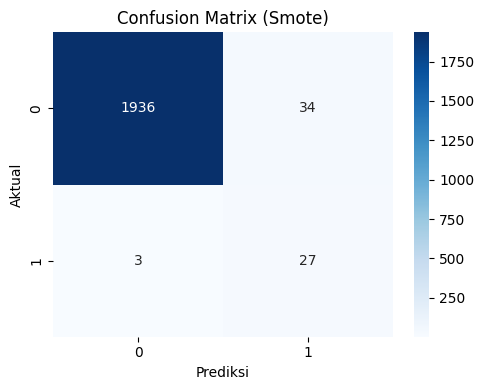

In [39]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(5,4))
sns.heatmap(cm_smote, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix (Smote)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [40]:
y_prob_smote = smote_pipeline.predict_proba(X_test)[:,1]

In [41]:
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f'ROC AUC score smote = {roc_auc_smote}')

ROC AUC score smote = 0.9962267343485618


**Model Hyperparameter Tuning Menggunakan Model Balanced**

In [53]:
param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01]
    },
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__degree": [2, 3]
    }
]

In [54]:
from sklearn.model_selection import GridSearchCV

grid_svc = GridSearchCV(
    estimator= balanced_pipeline,
    param_grid= params_grid,
    cv=5,
    scoring='f1',
    n_jobs = -1,
    verbose = 3
)

In [55]:
grid_svc.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['amount',
                                                                          'device_trust_score',
                                                                          'velocity_last_24h',
                                                                          'cardholder_age'])])),
                                       ('model',
                                        SVC(class_weight='balanced',
                                            probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100], 'model__degree': [2, 3],
                         'model__gamma': ['scale', 'auto', 0.01, 0.1],
                         'model__kernel': ['linear', 'rbf', 'poly']},
             scoring='f1', verbose=3)

In [56]:
print(grid_svc.best_params_)

{'model__C': 100, 'model__degree': 2, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


In [57]:
best_svc = grid_svc.best_estimator_

In [58]:
y_pred = best_svc.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Akurasi model : {accuracy:.4f}')
print(f'Precision model : {precision:.4f}')
print(f'Recall model : {recall:.4f}')
print(classification_report(y_test, y_pred))

Akurasi model : 0.9910
Precision model : 0.6500
Recall model : 0.8667
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.65      0.87      0.74        30

    accuracy                           0.99      2000
   macro avg       0.82      0.93      0.87      2000
weighted avg       0.99      0.99      0.99      2000



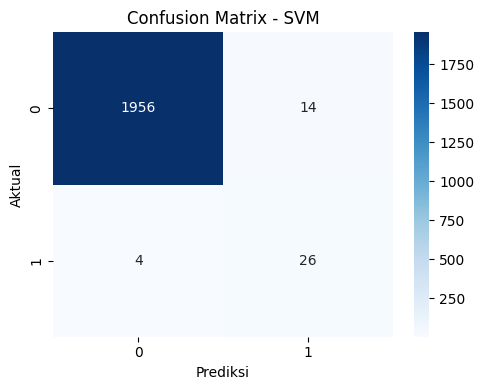

In [51]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, fmt='d', annot=True, cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [52]:
y_prob = best_svc.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC AUC score : {roc_auc:.4f}')

ROC AUC score : 0.9949


In [61]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_svc,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [62]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : result.importances_mean
})

In [63]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [64]:
feature_importance

,Feature,Importance
5,device_trust_score,0.442044
3,foreign_transaction,0.399185
2,hour_cos,0.364651
4,location_mismatch,0.231323
1,hour_sin,0.219559
6,velocity_last_24h,0.138364
0,amount,0.009935
7,cardholder_age,-0.007193


/tmp/ipykernel_485/3888066237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


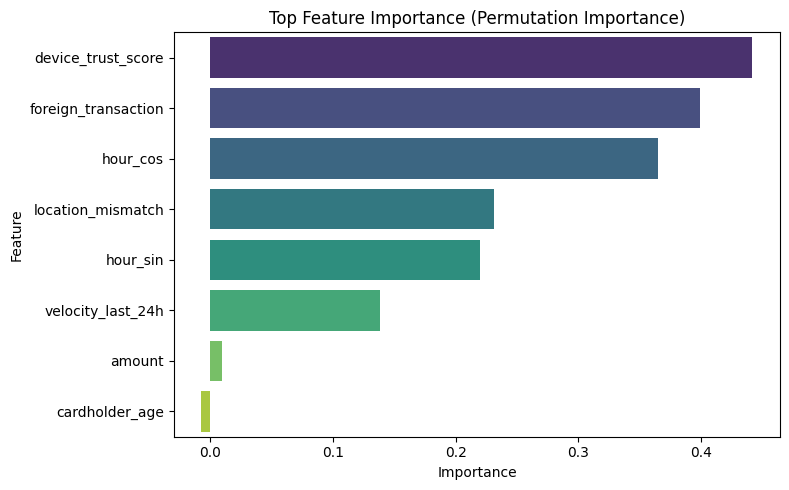

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top Feature Importance (Permutation Importance)")
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [66]:
import joblib
from google.colab import files

joblib.dump(best_svc, 'Support_Vector_Machine.joblib')
files.download('Support_Vector_Machine.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>